# ARTEFACTA Copiloto — Notebook de Analítica y Machine Learning
## ETL · EDA · Modelo supervisado · Segmentación de clientes

**Fuente:** `DATASET_ARTEFACTA.csv`, exportado de una vista Oracle del proyecto ARTEFACTA.  
**Objetivo:** convertir el histórico transaccional en evidencia analítica reproducible para apoyar decisiones comerciales del MVP.

> **Google Colab:** este notebook es compatible con Colab. El botón/enlace permanente se agregará cuando el archivo sea publicado en un repositorio GitHub, porque la URL depende de `usuario/repositorio/rama/ruta`.

## 0. Diseño analítico

El notebook sigue cinco principios:

1. **Trazabilidad:** los resultados provienen del dataset Oracle entregado.
2. **ETL auditable:** se verifican tipos, fechas, nulos, duplicados y reglas aritméticas.
3. **EDA interpretable:** cada visualización incluye lectura de negocio.
4. **Supervisado sin fuga temporal:** se intenta predecir si un cliente volverá a comprar en los siguientes 90 días usando sólo información disponible en la fecha de corte.
5. **Segmentación:** se construyen variables RFM y de comportamiento para identificar grupos de clientes mediante K-Means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    silhouette_score, davies_bouldin_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("DATASET_ARTEFACTA.csv")
if not DATA_PATH.exists():
    # En el entorno donde se generó el entregable el archivo está montado aquí.
    # En el repositorio GitHub el archivo está en la carpeta data/.
    candidatos = [Path("../data/DATASET_ARTEFACTA.csv"), Path("data/DATASET_ARTEFACTA.csv"),
                  Path("/mnt/data/DATASET_ARTEFACTA.csv")]
    encontrados = [p for p in candidatos if p.exists()]
    if encontrados:
        DATA_PATH = encontrados[0]
    else:
        raise FileNotFoundError(
            "No se encontró DATASET_ARTEFACTA.csv. En Colab, súbelo al panel Files."
        )
print("Fuente:", DATA_PATH)

Fuente: DATASET_ARTEFACTA.csv


## 1. Carga y reconocimiento del dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Filas: {len(df_raw):,}")
print(f"Columnas: {df_raw.shape[1]}")
display(df_raw.head())

Filas: 132,766
Columnas: 20


,VENTA_ID,FECHA_VENTA,AÑO,MES,CLIENTE_ID,CLIENTE,VENDEDOR_ID,VENDEDOR,ITEM,PRODUCTO_ID,PRODUCTO,CATEGORIA_ID,SKU,CATEGORIA,CANTIDAD,PRECIO_UNITARIO,DESCUENTO,IMPORTE,IMPUESTOS,TOTAL
0,80,26/07/2026,2026,07 JULIO,310,Laura Flores Ramírez,2,Sofía Flores,219,451,Nova Electrónica Modelo 451,1,SKU-01-00451,Electrónica,4,13943.07,0.0,55772.28,8923.56,64695.84
1,80,26/07/2026,2026,07 JULIO,310,Laura Flores Ramírez,2,Sofía Flores,220,8,Vision Muebles Modelo 008,8,SKU-08-00008,Muebles,1,22039.36,0.0,22039.36,3526.30,25565.66
2,81,31/03/2025,2025,03 MARZO,351,Daniel Jiménez Torres,49,Carlos Pérez,221,60,Select Iluminación Modelo 060,10,SKU-10-00060,Iluminación,1,3847.21,0.0,3847.21,615.55,4462.76
3,81,31/03/2025,2025,03 MARZO,351,Daniel Jiménez Torres,49,Carlos Pérez,222,443,Vision Limpieza Modelo 443,43,SKU-43-00443,Limpieza,2,7446.36,0.0,14892.72,2382.84,17275.56
4,82,18/07/2026,2026,07 JULIO,871,Miguel Sánchez Vargas,2,Sofía Flores,223,411,Maxi Herramientas Modelo 411,11,SKU-11-00411,Herramientas,2,11993.34,3598.0,20388.68,3262.19,23650.87


In [3]:
resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "unicos": df_raw.nunique()
})
display(resumen)

,tipo,nulos,unicos
VENTA_ID,int64,0,50000
FECHA_VENTA,object,0,731
AÑO,int64,0,3
MES,object,0,12
CLIENTE_ID,int64,0,1000
CLIENTE,object,0,90
VENDEDOR_ID,int64,0,50
VENDEDOR,object,0,6
ITEM,int64,0,132766
PRODUCTO_ID,int64,0,500


**Interpretación.** La vista tiene granularidad de **línea de venta**: una misma `VENTA_ID` puede aparecer en varias filas porque cada fila representa un artículo/producto de la operación. Por ello, para indicadores de ticket se debe agregar primero a nivel de venta y no tratar cada renglón como una venta independiente.

## 2. ETL y controles de calidad

In [4]:
df = df_raw.copy()

# Tipificación
df["FECHA_VENTA"] = pd.to_datetime(df["FECHA_VENTA"], format="%d/%m/%Y", errors="coerce")

numeric_cols = [
    "VENTA_ID","AÑO","CLIENTE_ID","VENDEDOR_ID","ITEM","PRODUCTO_ID",
    "CATEGORIA_ID","CANTIDAD","PRECIO_UNITARIO","DESCUENTO",
    "IMPORTE","IMPUESTOS","TOTAL"
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

auditoria = {
    "filas": len(df),
    "columnas": df.shape[1],
    "nulos_totales": int(df.isna().sum().sum()),
    "duplicados_exactos": int(df.duplicated().sum()),
    "fechas_invalidas": int(df["FECHA_VENTA"].isna().sum()),
    "cantidad_no_positiva": int((df["CANTIDAD"] <= 0).sum()),
    "precio_negativo": int((df["PRECIO_UNITARIO"] < 0).sum()),
    "descuento_negativo": int((df["DESCUENTO"] < 0).sum()),
    "total_no_positivo": int((df["TOTAL"] <= 0).sum()),
}
display(pd.DataFrame.from_dict(auditoria, orient="index", columns=["resultado"]))

,resultado
filas,132766
columnas,20
nulos_totales,0
duplicados_exactos,0
fechas_invalidas,0
cantidad_no_positiva,0
precio_negativo,0
descuento_negativo,0
total_no_positivo,0


In [5]:
# Controles aritméticos con tolerancia por redondeo monetario
importe_esperado = df["CANTIDAD"] * df["PRECIO_UNITARIO"] - df["DESCUENTO"]
total_esperado = df["IMPORTE"] + df["IMPUESTOS"]

controles = pd.DataFrame({
    "control": [
        "IMPORTE = CANTIDAD × PRECIO_UNITARIO - DESCUENTO",
        "TOTAL = IMPORTE + IMPUESTOS"
    ],
    "inconsistencias_mayores_0.05": [
        int(((df["IMPORTE"] - importe_esperado).abs() > .05).sum()),
        int(((df["TOTAL"] - total_esperado).abs() > .05).sum())
    ]
})
display(controles)

print("Periodo:", df["FECHA_VENTA"].min().date(), "a", df["FECHA_VENTA"].max().date())
print("Ventas únicas:", f'{df["VENTA_ID"].nunique():,}')
print("Clientes:", f'{df["CLIENTE_ID"].nunique():,}')
print("Productos:", f'{df["PRODUCTO_ID"].nunique():,}')
print("Vendedores:", f'{df["VENDEDOR_ID"].nunique():,}')
print("Categorías:", f'{df["CATEGORIA_ID"].nunique():,}')

,control,inconsistencias_mayores_0.05
0,IMPORTE = CANTIDAD × PRECIO_UNITARIO - DESCUENTO,0
1,TOTAL = IMPORTE + IMPUESTOS,0


Periodo: 2024-08-27 a 2026-08-27
Ventas únicas: 50,000
Clientes: 1,000
Productos: 500
Vendedores: 50
Categorías: 50


**Interpretación ETL.** Estos controles determinan si la exportación de Oracle es analíticamente consistente. No se eliminan registros de forma automática salvo que una regla explícita lo justifique. La validación de `IMPORTE` y `TOTAL` es especialmente importante porque evita entrenar modelos sobre importes incompatibles con la lógica transaccional.

## 3. Construcción de datasets analíticos

In [6]:
# Nivel venta: evita confundir líneas de detalle con tickets
ventas = (
    df.groupby(["VENTA_ID","FECHA_VENTA","CLIENTE_ID","CLIENTE","VENDEDOR_ID","VENDEDOR"], as_index=False)
      .agg(
          ITEMS=("ITEM","count"),
          UNIDADES=("CANTIDAD","sum"),
          SUBTOTAL=("IMPORTE","sum"),
          DESCUENTO=("DESCUENTO","sum"),
          IMPUESTOS=("IMPUESTOS","sum"),
          TOTAL_VENTA=("TOTAL","sum")
      )
)
ventas["MES_PERIODO"] = ventas["FECHA_VENTA"].dt.to_period("M").astype(str)
print("Ventas agregadas:", f"{len(ventas):,}")
display(ventas.head())

Ventas agregadas: 50,000


,VENTA_ID,FECHA_VENTA,CLIENTE_ID,CLIENTE,VENDEDOR_ID,VENDEDOR,ITEMS,UNIDADES,SUBTOTAL,DESCUENTO,IMPUESTOS,TOTAL_VENTA,MES_PERIODO
0,1,2024-12-19,79,Miguel Díaz Martínez,50,Sofía Flores,2,7,150232.72,9515.07,24037.24,174269.96,2024-12
1,2,2025-05-08,321,Andrés Jiménez Torres,29,Andrés Flores,4,8,126665.15,5569.50,20266.43,146931.58,2025-05
2,3,2025-06-15,262,Patricia González Pérez,21,Daniel García,3,7,107155.35,1803.43,17144.86,124300.21,2025-06
3,4,2026-06-17,262,Patricia González Pérez,35,Andrés Flores,1,1,19008.78,1000.46,3041.40,22050.18,2026-06
4,5,2026-08-06,318,Fernanda Rodríguez Rodríguez,37,Carlos Pérez,2,4,27809.30,0.00,4449.49,32258.79,2026-08


## 4. EDA — evolución de ventas

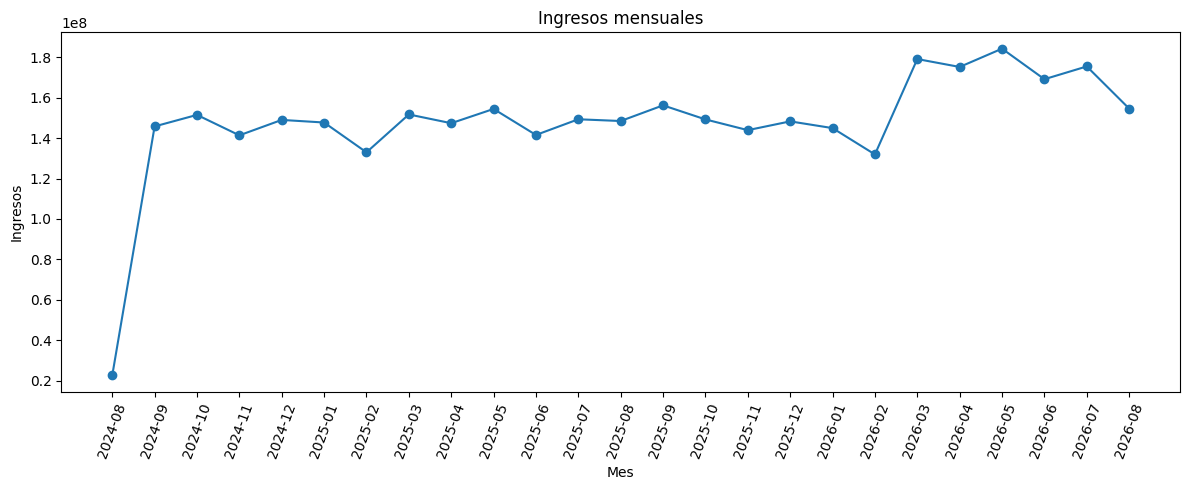

**Interpretación.** El mayor ingreso mensual del periodo ocurre en **2026-05** con **184,252,457.60**, mientras que el menor se observa en **2024-08** con **22,610,894.28**. La serie permite distinguir variaciones temporales que deben considerarse antes de atribuir cambios comerciales únicamente al modelo.

In [7]:
mensual = ventas.groupby("MES_PERIODO", as_index=False).agg(
    VENTAS=("VENTA_ID","nunique"),
    INGRESOS=("TOTAL_VENTA","sum"),
    TICKET_PROMEDIO=("TOTAL_VENTA","mean")
)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(mensual["MES_PERIODO"], mensual["INGRESOS"], marker="o")
ax.set_title("Ingresos mensuales")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

max_mes = mensual.loc[mensual["INGRESOS"].idxmax()]
min_mes = mensual.loc[mensual["INGRESOS"].idxmin()]
display(Markdown(
    f"**Interpretación.** El mayor ingreso mensual del periodo ocurre en **{max_mes['MES_PERIODO']}** "
    f"con **{max_mes['INGRESOS']:,.2f}**, mientras que el menor se observa en **{min_mes['MES_PERIODO']}** "
    f"con **{min_mes['INGRESOS']:,.2f}**. La serie permite distinguir variaciones temporales que deben "
    "considerarse antes de atribuir cambios comerciales únicamente al modelo."
))

## 5. EDA — categorías

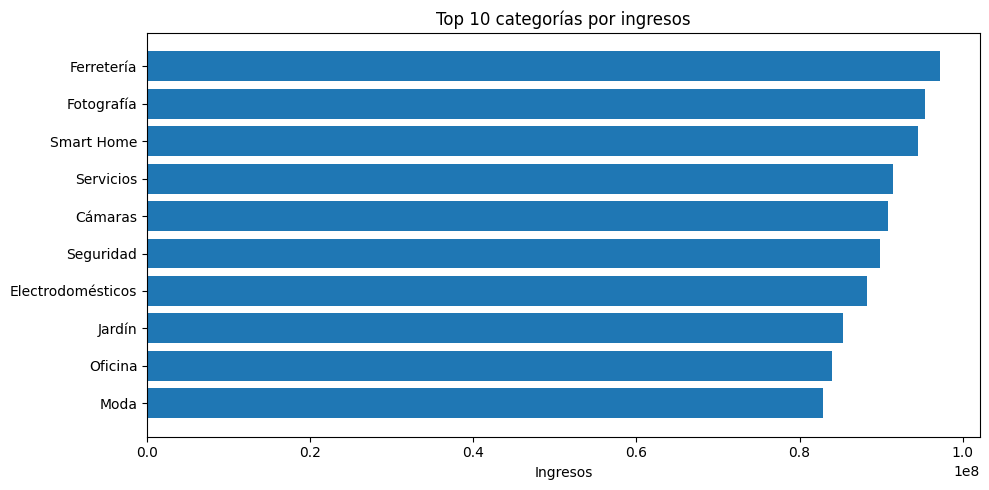

**Interpretación.** La categoría con mayor ingreso es **Ferretería**, con **97,260,220.19**. Este ranking sirve para distinguir categorías de alto valor de aquellas cuyo aporte puede depender más de volumen que de precio.

In [8]:
cat = (df.groupby("CATEGORIA", as_index=False)
         .agg(INGRESOS=("TOTAL","sum"), UNIDADES=("CANTIDAD","sum"))
         .sort_values("INGRESOS", ascending=False)
         .head(10))

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(cat["CATEGORIA"][::-1], cat["INGRESOS"][::-1])
ax.set_title("Top 10 categorías por ingresos")
ax.set_xlabel("Ingresos")
plt.tight_layout()
plt.show()

top = cat.iloc[0]
display(Markdown(
    f"**Interpretación.** La categoría con mayor ingreso es **{top['CATEGORIA']}**, "
    f"con **{top['INGRESOS']:,.2f}**. Este ranking sirve para distinguir categorías de alto valor "
    "de aquellas cuyo aporte puede depender más de volumen que de precio."
))

## 6. EDA — productos

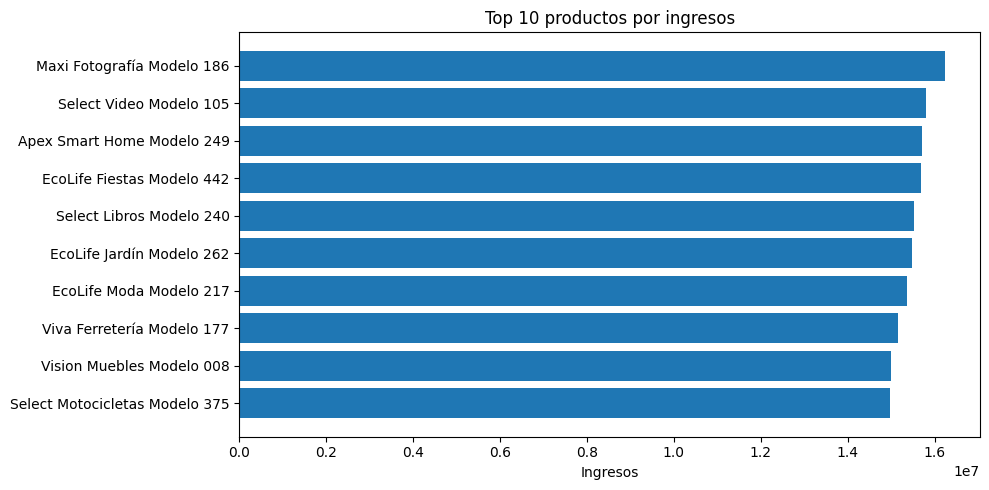

**Interpretación.** El producto líder por ingreso es **Maxi Fotografía Modelo 186** con **16,234,211.09**. El resultado ayuda a priorizar análisis de disponibilidad, promociones y venta cruzada, pero no debe interpretarse por sí solo como rentabilidad porque el dataset no contiene costo ni margen.

In [9]:
prod = (df.groupby(["PRODUCTO_ID","PRODUCTO"], as_index=False)
          .agg(INGRESOS=("TOTAL","sum"), UNIDADES=("CANTIDAD","sum"))
          .sort_values("INGRESOS", ascending=False)
          .head(10))

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(prod["PRODUCTO"][::-1], prod["INGRESOS"][::-1])
ax.set_title("Top 10 productos por ingresos")
ax.set_xlabel("Ingresos")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Interpretación.** El producto líder por ingreso es **{prod.iloc[0]['PRODUCTO']}** "
    f"con **{prod.iloc[0]['INGRESOS']:,.2f}**. El resultado ayuda a priorizar análisis de disponibilidad, "
    "promociones y venta cruzada, pero no debe interpretarse por sí solo como rentabilidad porque el dataset "
    "no contiene costo ni margen."
))

## 7. EDA — vendedores

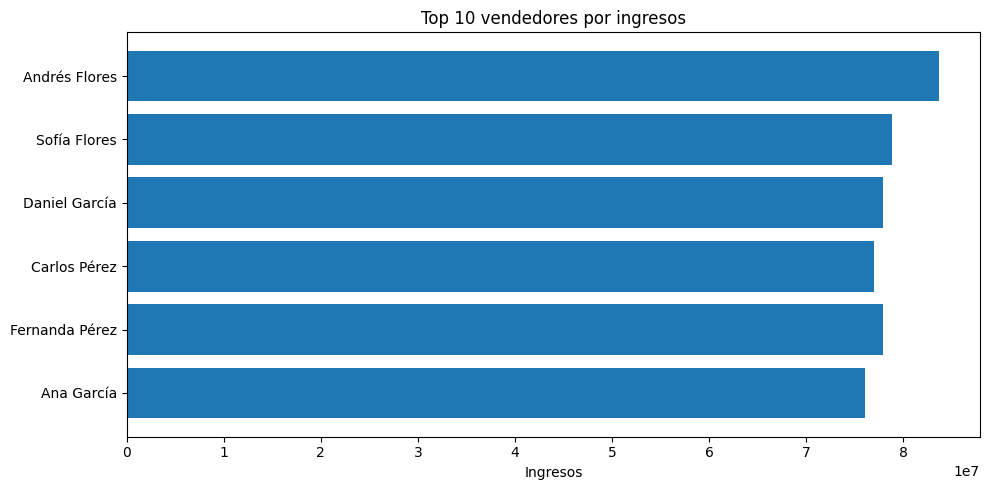

**Interpretación.** **Andrés Flores** encabeza el ingreso acumulado dentro del periodo analizado. La comparación debe complementarse con número de operaciones y ticket promedio; ingreso total por sí solo no demuestra productividad causal porque las carteras de clientes pueden ser diferentes.

In [10]:
vend = (ventas.groupby(["VENDEDOR_ID","VENDEDOR"], as_index=False)
          .agg(INGRESOS=("TOTAL_VENTA","sum"),
               NUM_VENTAS=("VENTA_ID","nunique"),
               TICKET_PROMEDIO=("TOTAL_VENTA","mean"))
          .sort_values("INGRESOS", ascending=False)
          .head(10))

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(vend["VENDEDOR"][::-1], vend["INGRESOS"][::-1])
ax.set_title("Top 10 vendedores por ingresos")
ax.set_xlabel("Ingresos")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Interpretación.** **{vend.iloc[0]['VENDEDOR']}** encabeza el ingreso acumulado dentro del periodo analizado. "
    "La comparación debe complementarse con número de operaciones y ticket promedio; ingreso total por sí solo "
    "no demuestra productividad causal porque las carteras de clientes pueden ser diferentes."
))

## 8. EDA — distribución del ticket

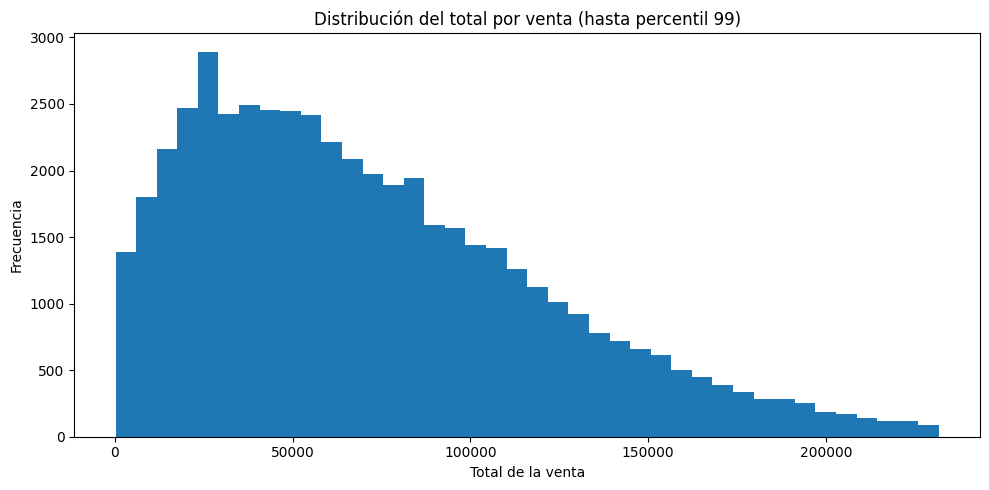

**Interpretación.** El ticket promedio es **73,926.83** y la mediana **63,446.76**. Se limita la visualización al percentil 99 únicamente para hacer legible el histograma; los valores superiores permanecen en los datos.

In [11]:
q99 = ventas["TOTAL_VENTA"].quantile(.99)
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(ventas.loc[ventas["TOTAL_VENTA"] <= q99, "TOTAL_VENTA"], bins=40)
ax.set_title("Distribución del total por venta (hasta percentil 99)")
ax.set_xlabel("Total de la venta")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Interpretación.** El ticket promedio es **{ventas['TOTAL_VENTA'].mean():,.2f}** y la mediana "
    f"**{ventas['TOTAL_VENTA'].median():,.2f}**. Se limita la visualización al percentil 99 "
    "únicamente para hacer legible el histograma; los valores superiores permanecen en los datos."
))

# 9. Modelo supervisado — propensión de recompra a 90 días

### Definición de la variable objetivo
Se crean cortes mensuales históricos. Para cada cliente y fecha de corte se calculan variables **sólo con compras anteriores o iguales al corte**.  
`TARGET_RECOMPRA_90D = 1` cuando el cliente registra al menos una venta en los **90 días posteriores**.

Esto convierte el problema en una pregunta accionable para ARTEFACTA:  
> *Con la información conocida hoy, ¿qué clientes tienen mayor propensión a volver a comprar durante los próximos 90 días?*

Los últimos 90 días del dataset no se usan como cortes de entrenamiento porque no disponen de una ventana futura completa para etiquetar.

In [12]:
tx = ventas[["CLIENTE_ID","FECHA_VENTA","VENTA_ID","TOTAL_VENTA","UNIDADES"]].copy()
fecha_min = tx["FECHA_VENTA"].min()
fecha_max = tx["FECHA_VENTA"].max()

# Cortes a fin de mes; exigimos al menos 6 meses de historia y 90 días futuros completos.
inicio = (fecha_min + pd.DateOffset(months=6)).to_period("M").to_timestamp("M")
fin = (fecha_max - pd.Timedelta(days=90)).to_period("M").to_timestamp("M")
cortes = pd.date_range(inicio, fin, freq="ME")

clientes = tx["CLIENTE_ID"].unique()
filas = []

for corte in cortes:
    hist = tx[tx["FECHA_VENTA"] <= corte]
    fut = tx[(tx["FECHA_VENTA"] > corte) & (tx["FECHA_VENTA"] <= corte + pd.Timedelta(days=90))]

    g = hist.groupby("CLIENTE_ID").agg(
        ULTIMA_COMPRA=("FECHA_VENTA","max"),
        FRECUENCIA=("VENTA_ID","nunique"),
        MONETARIO=("TOTAL_VENTA","sum"),
        TICKET_PROM=("TOTAL_VENTA","mean"),
        UNIDADES=("UNIDADES","sum")
    )
    g["RECENCIA_DIAS"] = (corte - g["ULTIMA_COMPRA"]).dt.days
    g["ANTIGUEDAD_DIAS"] = (corte - hist.groupby("CLIENTE_ID")["FECHA_VENTA"].min()).dt.days
    g["TARGET_RECOMPRA_90D"] = g.index.isin(fut["CLIENTE_ID"].unique()).astype(int)
    g["CORTE"] = corte
    filas.append(g.reset_index())

model_df = pd.concat(filas, ignore_index=True)
features = ["RECENCIA_DIAS","FRECUENCIA","MONETARIO","TICKET_PROM","UNIDADES","ANTIGUEDAD_DIAS"]

print("Observaciones cliente-corte:", f"{len(model_df):,}")
print("Cortes:", model_df["CORTE"].min().date(), "a", model_df["CORTE"].max().date())
print("Tasa de recompra 90d:", f"{model_df['TARGET_RECOMPRA_90D'].mean():.2%}")
display(model_df.head())

Observaciones cliente-corte: 13,407
Cortes: 2025-02-28 a 2026-05-31
Tasa de recompra 90d: 92.32%


,CLIENTE_ID,ULTIMA_COMPRA,FRECUENCIA,MONETARIO,TICKET_PROM,UNIDADES,RECENCIA_DIAS,ANTIGUEDAD_DIAS,TARGET_RECOMPRA_90D,CORTE
0,1,2025-02-28,31,2282465.56,73627.921290,167,0,169,1,2025-02-28
1,2,2025-02-27,43,2955440.47,68731.173721,217,1,175,1,2025-02-28
2,3,2025-02-24,23,1428346.88,62102.038261,111,4,179,1,2025-02-28
3,4,2025-02-24,33,2155295.47,65311.983939,159,4,176,1,2025-02-28
4,5,2025-02-24,27,1866069.35,69113.679630,139,4,185,1,2025-02-28


## 9.1 Separación temporal de entrenamiento y prueba

In [13]:
cortes_ordenados = sorted(model_df["CORTE"].unique())
n_test = max(2, int(np.ceil(len(cortes_ordenados)*0.25)))
test_cuts = cortes_ordenados[-n_test:]

train = model_df[~model_df["CORTE"].isin(test_cuts)].copy()
test = model_df[model_df["CORTE"].isin(test_cuts)].copy()

X_train, y_train = train[features], train["TARGET_RECOMPRA_90D"]
X_test, y_test = test[features], test["TARGET_RECOMPRA_90D"]

print("Train:", X_train.shape, "|", train["CORTE"].min().date(), "a", train["CORTE"].max().date())
print("Test :", X_test.shape, "|", test["CORTE"].min().date(), "a", test["CORTE"].max().date())

Train: (9600, 6) | 2025-02-28 a 2026-01-31
Test : (3807, 6) | 2026-02-28 a 2026-05-31


## 9.2 Línea base y modelos candidatos

In [14]:
modelos = {
    "Baseline mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
    )
}

resultados = []
ajustados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    ajustados[nombre] = modelo
    pred = modelo.predict(X_test)
    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, proba)
    else:
        auc = np.nan
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred,zero_division=0),
        "Recall": recall_score(y_test,pred,zero_division=0),
        "F1": f1_score(y_test,pred,zero_division=0),
        "ROC_AUC": auc
    })

metricas = pd.DataFrame(resultados).sort_values("ROC_AUC", ascending=False, na_position="last")
display(metricas.round(4))

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.9480,0.9530,0.9865,0.9695,0.9736
1,Regresión logística,0.9241,0.9279,0.9859,0.9560,0.9649
0,Baseline mayoritaria,0.8369,0.8369,1.0000,0.9112,0.5000


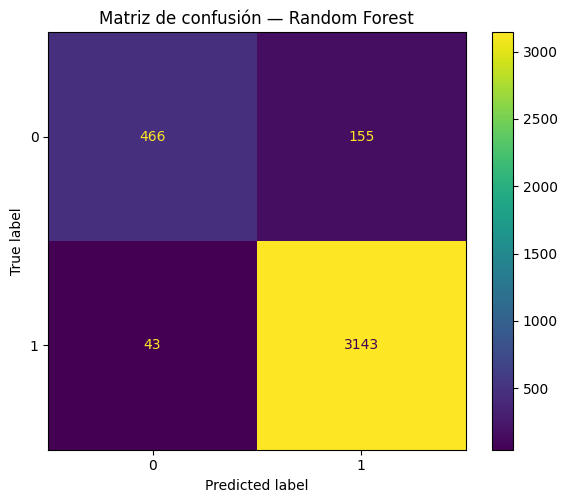

**Interpretación.** El modelo candidato con mayor ROC-AUC en el bloque temporal de prueba es **Random Forest** (ROC-AUC **0.974**, F1 **0.969**). La matriz de confusión permite observar errores positivos y negativos; para una campaña comercial el umbral de decisión debe elegirse según el costo de contactar a un cliente frente al valor de recuperar una recompra.

In [15]:
candidatos = metricas[metricas["Modelo"] != "Baseline mayoritaria"].dropna(subset=["ROC_AUC"])
mejor_nombre = candidatos.iloc[0]["Modelo"]
mejor = ajustados[mejor_nombre]

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(mejor, X_test, y_test, ax=ax)
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
plt.tight_layout()
plt.show()

bestrow = candidatos.iloc[0]
display(Markdown(
    f"**Interpretación.** El modelo candidato con mayor ROC-AUC en el bloque temporal de prueba es "
    f"**{mejor_nombre}** (ROC-AUC **{bestrow['ROC_AUC']:.3f}**, F1 **{bestrow['F1']:.3f}**). "
    "La matriz de confusión permite observar errores positivos y negativos; para una campaña comercial "
    "el umbral de decisión debe elegirse según el costo de contactar a un cliente frente al valor de recuperar una recompra."
))

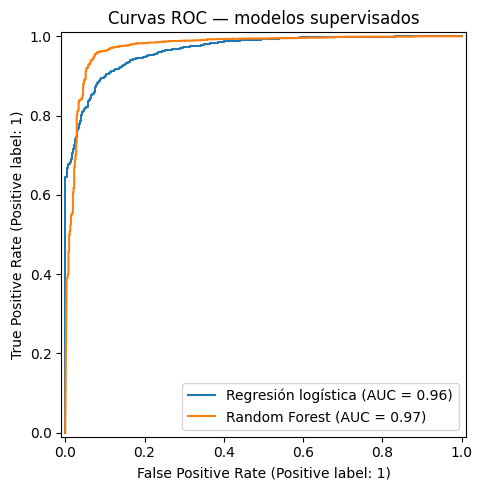

**Interpretación.** La curva ROC compara capacidad de discriminación a diferentes umbrales. Un ROC-AUC cercano a 0.5 equivale a discriminación débil; valores superiores indican mejor ordenamiento de clientes con y sin recompra. La evaluación temporal es más exigente y más realista que mezclar aleatoriamente observaciones de diferentes fechas.

In [16]:
fig, ax = plt.subplots(figsize=(7,5))
for nombre in ["Regresión logística","Random Forest"]:
    RocCurveDisplay.from_estimator(ajustados[nombre], X_test, y_test, ax=ax, name=nombre)
ax.set_title("Curvas ROC — modelos supervisados")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretación.** La curva ROC compara capacidad de discriminación a diferentes umbrales. "
    "Un ROC-AUC cercano a 0.5 equivale a discriminación débil; valores superiores indican mejor ordenamiento "
    "de clientes con y sin recompra. La evaluación temporal es más exigente y más realista que mezclar aleatoriamente "
    "observaciones de diferentes fechas."
))

# 10. Modelo no supervisado — segmentación RFM

Para el estado más reciente del dataset se construye una tabla por cliente con:

- **Recencia:** días desde la última compra.
- **Frecuencia:** número de ventas.
- **Monetario:** ingreso histórico.
- **Ticket promedio.**
- **Unidades compradas.**
- **Diversidad:** productos y categorías diferentes.

Las variables monetarias y de frecuencia se transforman con `log1p` antes de estandarizar para reducir el efecto de distribuciones sesgadas.

In [17]:
corte_rfm = ventas["FECHA_VENTA"].max()

rfm_base = ventas.groupby("CLIENTE_ID").agg(
    ULTIMA_COMPRA=("FECHA_VENTA","max"),
    FRECUENCIA=("VENTA_ID","nunique"),
    MONETARIO=("TOTAL_VENTA","sum"),
    TICKET_PROM=("TOTAL_VENTA","mean"),
    UNIDADES=("UNIDADES","sum")
)

div = df.groupby("CLIENTE_ID").agg(
    PRODUCTOS_DISTINTOS=("PRODUCTO_ID","nunique"),
    CATEGORIAS_DISTINTAS=("CATEGORIA_ID","nunique")
)

rfm = rfm_base.join(div)
rfm["RECENCIA_DIAS"] = (corte_rfm - rfm["ULTIMA_COMPRA"]).dt.days

cluster_features = [
    "RECENCIA_DIAS","FRECUENCIA","MONETARIO","TICKET_PROM",
    "UNIDADES","PRODUCTOS_DISTINTOS","CATEGORIAS_DISTINTAS"
]

Xc = rfm[cluster_features].copy()
for c in cluster_features:
    Xc[c] = np.log1p(Xc[c])
scaler = StandardScaler()
Xcs = scaler.fit_transform(Xc)

display(rfm[cluster_features].describe().round(2))

,RECENCIA_DIAS,FRECUENCIA,MONETARIO,TICKET_PROM,UNIDADES,PRODUCTOS_DISTINTOS,CATEGORIAS_DISTINTAS
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,48.08,50.00,3696341.49,73939.49,268.14,108.74,39.52
std,84.70,39.39,2929689.39,9926.68,212.35,73.68,9.73
min,0.00,4.00,169680.57,33936.11,14.00,10.00,9.00
25%,3.00,18.00,1369281.04,68359.73,100.00,46.75,32.00
50%,10.00,33.00,2423281.20,73851.96,176.00,79.00,41.00
75%,29.00,80.00,5934867.12,79853.85,432.25,174.00,49.00
max,377.00,162.00,12505706.65,119394.10,923.00,297.00,50.00


## 10.1 Selección de K

,k,silhouette,davies_bouldin,inercia
0,2,0.4519,0.7766,3234.7354
1,3,0.4050,1.0767,2244.8153
2,4,0.3944,1.1389,1857.4342
3,5,0.3976,1.0309,1602.2765
4,6,0.3686,1.0677,1427.5702
5,7,0.3744,1.0875,1299.7855
6,8,0.2813,1.2108,1197.2984


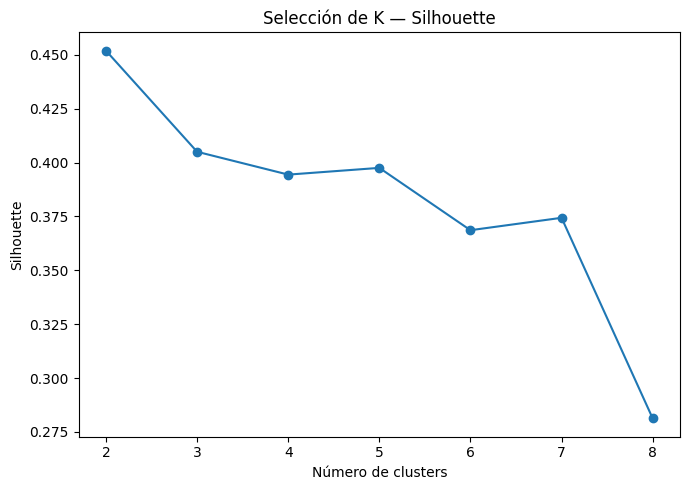

**Interpretación.** Entre k=2 y k=8, el mayor Silhouette corresponde a **k=2**. Este criterio favorece grupos compactos y separados. Davies-Bouldin se reporta como contraste: valores menores son preferibles. La selección estadística debe complementarse con utilidad comercial.

In [18]:
scores=[]
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(Xcs)
    scores.append({
        "k":k,
        "silhouette":silhouette_score(Xcs,labels),
        "davies_bouldin":davies_bouldin_score(Xcs,labels),
        "inercia":km.inertia_
    })
ks = pd.DataFrame(scores)
display(ks.round(4))

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(ks["k"], ks["silhouette"], marker="o")
ax.set_title("Selección de K — Silhouette")
ax.set_xlabel("Número de clusters")
ax.set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k = int(ks.loc[ks["silhouette"].idxmax(),"k"])
display(Markdown(
    f"**Interpretación.** Entre k=2 y k=8, el mayor Silhouette corresponde a **k={best_k}**. "
    "Este criterio favorece grupos compactos y separados. Davies-Bouldin se reporta como contraste: "
    "valores menores son preferibles. La selección estadística debe complementarse con utilidad comercial."
))

## 10.2 Entrenamiento y perfil de segmentos

In [19]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
rfm["CLUSTER"] = km.fit_predict(Xcs)

perfil = rfm.groupby("CLUSTER").agg(
    CLIENTES=("FRECUENCIA","size"),
    RECENCIA_DIAS=("RECENCIA_DIAS","mean"),
    FRECUENCIA=("FRECUENCIA","mean"),
    MONETARIO=("MONETARIO","mean"),
    TICKET_PROM=("TICKET_PROM","mean"),
    UNIDADES=("UNIDADES","mean"),
    PRODUCTOS_DISTINTOS=("PRODUCTOS_DISTINTOS","mean"),
    CATEGORIAS_DISTINTAS=("CATEGORIAS_DISTINTAS","mean")
).round(2)

display(perfil)

,CLIENTES,RECENCIA_DIAS,FRECUENCIA,MONETARIO,TICKET_PROM,UNIDADES,PRODUCTOS_DISTINTOS,CATEGORIAS_DISTINTAS
CLUSTER,,,,,,,,
0,595,75.71,22.34,1638849.15,73588.43,118.91,55.39,33.07
1,405,7.50,90.64,6719077.17,74455.24,487.37,187.13,48.99


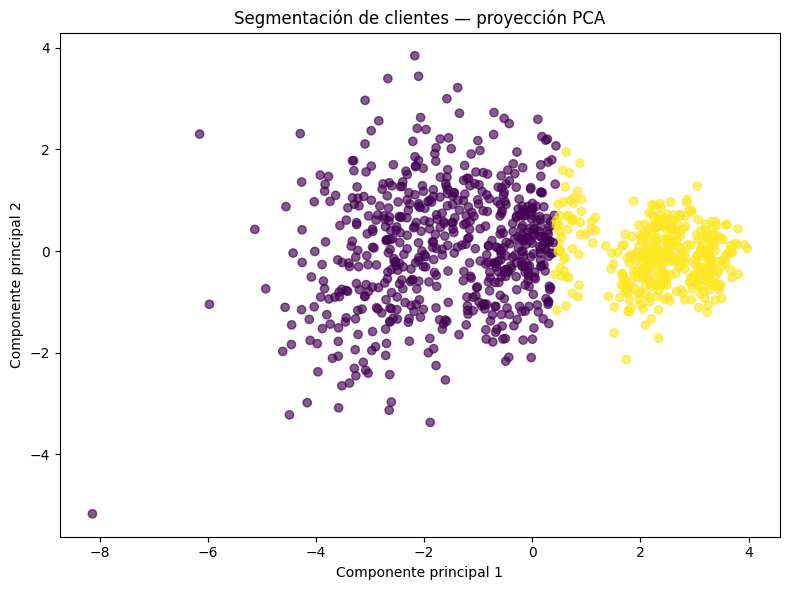

**Interpretación.** La proyección PCA representa en dos dimensiones una segmentación construida con **7 variables**. Los colores corresponden a los 2 clusters. PCA se utiliza aquí sólo para visualización; la asignación de clusters se realizó en el espacio completo de variables estandarizadas.

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xcs)

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(coords[:,0], coords[:,1], c=rfm["CLUSTER"], alpha=.65)
ax.set_title("Segmentación de clientes — proyección PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Interpretación.** La proyección PCA representa en dos dimensiones una segmentación construida con "
    f"**{len(cluster_features)} variables**. Los colores corresponden a los {best_k} clusters. "
    "PCA se utiliza aquí sólo para visualización; la asignación de clusters se realizó en el espacio completo "
    "de variables estandarizadas."
))

## 10.3 Lectura comercial automática de los clusters

In [21]:
globales = rfm[["RECENCIA_DIAS","FRECUENCIA","MONETARIO","TICKET_PROM"]].median()

for cl, row in perfil.iterrows():
    rasgos=[]
    rasgos.append("recencia baja" if row["RECENCIA_DIAS"] < globales["RECENCIA_DIAS"] else "recencia alta")
    rasgos.append("frecuencia alta" if row["FRECUENCIA"] > globales["FRECUENCIA"] else "frecuencia baja")
    rasgos.append("valor monetario alto" if row["MONETARIO"] > globales["MONETARIO"] else "valor monetario bajo")
    print(f"Cluster {cl}: {int(row['CLIENTES'])} clientes — " + ", ".join(rasgos) + ".")

Cluster 0: 595 clientes — recencia alta, frecuencia baja, valor monetario bajo.
Cluster 1: 405 clientes — recencia baja, frecuencia alta, valor monetario alto.


**Interpretación.** Los nombres comerciales de los segmentos no se fijan antes de observar sus perfiles.  
En producción conviene traducir estos patrones a etiquetas comprensibles —por ejemplo, clientes activos de alto valor, clientes frecuentes de menor ticket o clientes con mayor recencia— y documentar la regla usada para cada etiqueta.

# 11. Conclusiones y criterio de puesta en producción

### Modelo supervisado
El clasificador de recompra es un **modelo de propensión**, no una garantía de compra. Antes de incorporarlo a ARTEFACTA Copiloto se recomienda:

- conservar la separación temporal en validaciones futuras;
- calibrar el umbral según costo de contacto y beneficio esperado;
- medir Precision/Recall/F1/ROC-AUC por periodo;
- registrar aceptación/rechazo de recomendaciones;
- monitorear drift de variables y desempeño;
- mantener al vendedor como responsable de la acción comercial.

### Segmentación
K-Means puede ejecutarse en batch y almacenar el segmento de cada cliente como atributo analítico. Debe monitorearse la estabilidad de clusters y revisarse su significado comercial después de reentrenamientos.

### Gobernanza
Los modelos no deben sustituir la fuente Oracle ni ejecutar SQL libre. El flujo recomendado es:

**Oracle → ETL validado → features versionadas → modelo → score/segmento → servicio C# controlado → ARTEFACTA Copiloto → decisión del usuario.**

### Limitaciones
El dataset contiene transacciones y totales, pero no costos/margen, campañas, contactos comerciales ni una etiqueta explícita de aceptación de recomendación. Por ello, el notebook puede modelar **recompra observada** y segmentación, pero no puede demostrar causalmente que una recomendación del Copiloto produzca una venta.

# 12. Publicación en GitHub y Google Colab

Una vez publicado el notebook en GitHub, el enlace permanente de Colab tendrá esta forma:

`https://colab.research.google.com/github/USUARIO/REPOSITORIO/blob/main/notebooks/ARTEFACTA_Oracle_ETL_EDA_ML.ipynb`

Se recomienda guardar en el repositorio:

```text
ARTEFACTA/
├── notebooks/
│   └── ARTEFACTA_Oracle_ETL_EDA_ML.ipynb
├── data/
│   └── README.md
├── requirements-ml.txt
└── README.md
```

Si el dataset contiene información que no deba publicarse, **no se sube el CSV al repositorio**. El README debe explicar cómo obtenerlo/exportarlo de Oracle y dónde colocarlo para reproducir el notebook.